Today's topics:
* a model function that `curve_fit` calls
* fitting a nonlinear model with `curve_fit`
* starting guesses with `p0`
* fitted parameters and standard errors

# Compressing a printed part

So far we have called every function ourselves.
Today we pass a function to `curve_fit`.
It calls that function for us.

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/4/4f/Compression_test-Universal_testing_machine.jpg/960px-Compression_test-Universal_testing_machine.jpg" alt="A cylindrical specimen sitting between the two flat steel platens of a universal testing machine, with the load cell above and a control panel to the side" width=360/>

*Photo by Cjp24, [CC BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0), [via Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Compression_test-Universal_testing_machine.jpg).*

Above: A composite cylinder in a compression test on an [Instron universal testing machine](https://en.wikipedia.org/wiki/Universal_testing_machine).
The upper platen moves down at a set speed while a load cell records the force.

Our data come from the same kind of test on a 3D printed part.
The machine logs platen position in inches and force in pounds.

A compressed part passes through stages.
At first the part is stiff and the force climbs quickly with each bit of displacement.
Then the structure gives way, and the same extra displacement adds less force.
Late in the test the internal voids close, the part becomes denser, and the force climbs steeply again.
We expect to see this shape in the data.

The file is the instrument's raw output.
The machine records compression as negative numbers.
We flip the sign, then subtract the first reading so the test starts at zero.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

compression = pd.read_csv('https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/compression_test.csv')
print(compression.columns)

position = -compression['Position(Linear:Position) (in)'].to_numpy()  # in
force = -compression['Force(Linear:Load) (lb)'].to_numpy()            # lb
position = position - position[0]
force = force - force[0]
print(len(position), 'readings')
print(f'position 0 to {np.max(position):.3f} in, force 0 to {np.max(force):.0f} lb')

Index(['Position(Linear:Position) (in)', 'Force(Linear:Load) (lb)'], dtype='object')
374 readings
position 0 to 0.465 in, force 0 to 4088 lb


Text(0, 0.5, 'force (lb)')

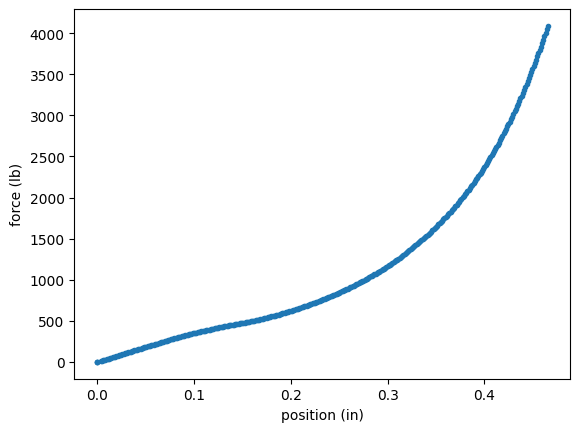

In [2]:
fig, ax = plt.subplots()
ax.plot(position, force, '.')
ax.set_xlabel('position (in)')
ax.set_ylabel('force (lb)')

The curve starts steep, flattens in the middle, and then climbs steeply again.
That is the shape we described.

We know one way to fit a model already, `stats.linregress`.
Let's try it first.

R2 = 0.847


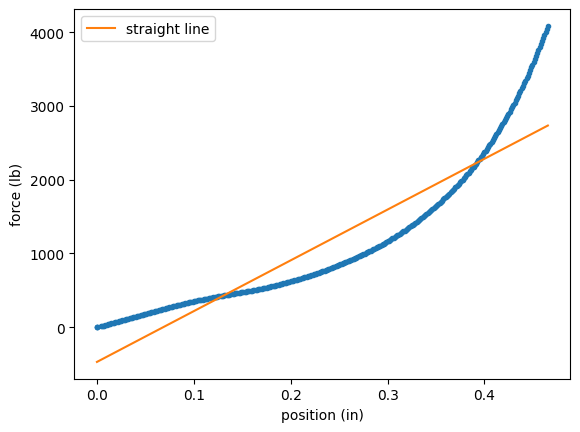

In [3]:
from scipy import stats

line = stats.linregress(position, force)
force_line = line.slope * position + line.intercept
print(f'R2 = {line.rvalue**2:.3f}')

ax.plot(position, force_line, '-', label='straight line')
ax.legend()
fig

The straight line goes through the middle of the data and misses the bend at both ends.
A straight line has no way to curve.

`linregress` only fits $y = m x + b$.
To fit a curve with a shape of our choosing, we write that shape as a Python function and give it to `curve_fit`.

# A function that `curve_fit` calls

`curve_fit` lives in `scipy.optimize`.
We give it our function, the $x$ data and the $y$ data.
It calls our function over and over with different trial values of the parameters, and it keeps the values that leave the smallest squared residuals.

Its docstring, from `help(optimize.curve_fit)`, specifies the required form.

> `f : callable`
> The model function, f(x, ...).
> It must take the independent variable as the first argument and the parameters to fit as separate remaining arguments.

So the first parameter is the $x$ data, and the parameters after it are the numbers to be fitted.
The function returns the predicted $y$ values.

Here is a toy model, a decay $y = a e^{-bx}$.
First we call it ourselves, as we did in L17 and L18.

In [4]:
def my_model(x, a, b):
    return a * np.exp(-b * x)

print(my_model(2, 4, 0.5))

1.4715177646857693


Now we will let `curve_fit` call it.
Here are six toy measurements that fall off with $x$.

Text(0, 0.5, 'y')

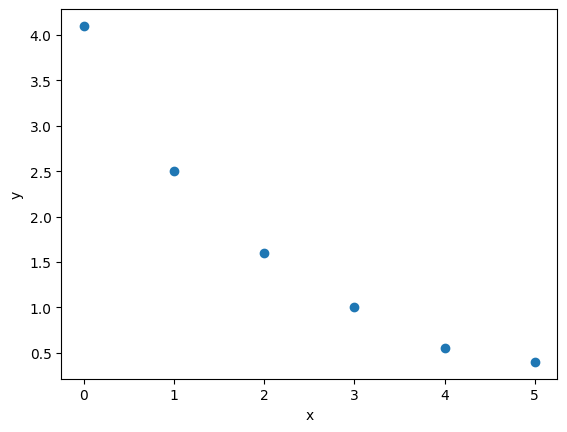

In [5]:
x_toy = np.array([0, 1, 2, 3, 4, 5])
y_toy = np.array([4.1, 2.5, 1.6, 1.0, 0.55, 0.4])

fig, ax = plt.subplots()
ax.plot(x_toy, y_toy, 'o')
ax.set_xlabel('x')
ax.set_ylabel('y')

We add a `print` to the function so we can watch the calls.
The call to `curve_fit` has no parentheses after `my_model`.
We are giving it the function itself, not a result from calling it.

In [6]:
from scipy import optimize

def my_model(x, a, b):
    print(f'a = {a:.3f}, b = {b:.3f}')
    return a * np.exp(-b * x)

popt, pcov = optimize.curve_fit(my_model, x_toy, y_toy)

a = 1.000, b = 1.000
a = 1.000, b = 1.000
a = 1.000, b = 1.000
a = 4.038, b = -2.476
a = 1.291, b = 0.538
a = 1.291, b = 0.538
a = 1.291, b = 0.538
a = 1.851, b = 0.318
a = 1.851, b = 0.318
a = 1.851, b = 0.318
a = 2.973, b = 0.346
a = 2.973, b = 0.346
a = 2.973, b = 0.346
a = 4.063, b = 0.492
a = 4.063, b = 0.492
a = 4.063, b = 0.492
a = 4.090, b = 0.478
a = 4.090, b = 0.478
a = 4.090, b = 0.478
a = 4.090, b = 0.478
a = 4.090, b = 0.478
a = 4.090, b = 0.478
a = 4.090, b = 0.478


Each printed line is one call to `my_model` made by `curve_fit`, not by us.
The first call uses the starting values, `a = 1` and `b = 1`.
Several calls repeat because `curve_fit` also nudges each parameter by a tiny amount and compares the error in each direction.
The nudges are too small to show at three decimals.
Then the values move, and the last values printed are the best fit.

`curve_fit` returns two items, `popt` and `pcov`.
The first holds the best-fit values of the parameters.

In [7]:
print(popt)

[4.09033193 0.4784712 ]


`popt` follows the order in the `def` line.
`popt[0]` is `a` and `popt[1]` is `b`.
The number of parameters comes from the `def` line as well, which is why the order and count matter.

We can plot the fitted function.
We remove the `print` and call `my_model` ourselves with the fitted values.

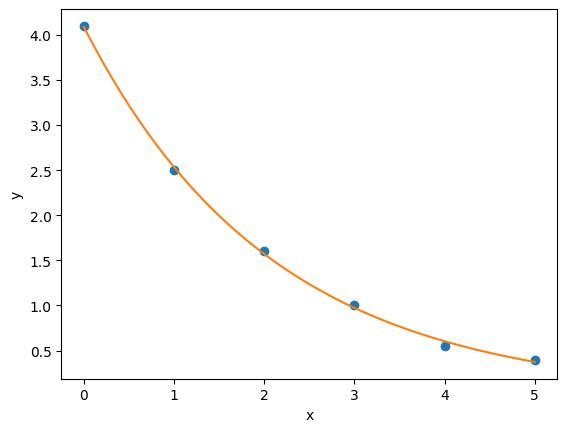

In [8]:
def my_model(x, a, b):
    return a * np.exp(-b * x)

a_fit, b_fit = popt
x_line = np.linspace(0, 5, 100)

ax.plot(x_line, my_model(x_line, a_fit, b_fit), '-')
fig

## The compression model

Back to the compression data.
We will try the simplest shape that rises steeply at large displacement,

$$F = a\,(e^{bx} - 1)$$

where $x$ is the position in inches.
This shape is zero at $x = 0$ and climbs faster and faster.
We chose it because it looks like the end of the curve, not from any theory.

The parameter $a$ is a force in lb and $b$ is in 1/in.
A docstring records that.

In [9]:
def exp_model(x, a, b):
    """Force in lb from F = a * (exp(b * x) - 1).

    x:  position in in (a number or an array)
    a:  force scale in lb
    b:  growth rate in 1/in
    """
    return a * (np.exp(b * x) - 1)

We use R² and residuals for every fit today.
We define the R² calculation once, the same R² as in L13.

In [10]:
def r_squared(y, y_fit):
    """R2 of a fit: 1 minus the squared misfit over the squared spread of y."""
    return 1 - np.sum((y - y_fit)**2) / np.sum((y - np.mean(y))**2)

Before fitting, let's try values by hand.
Each parameter changes the curve in its own way.

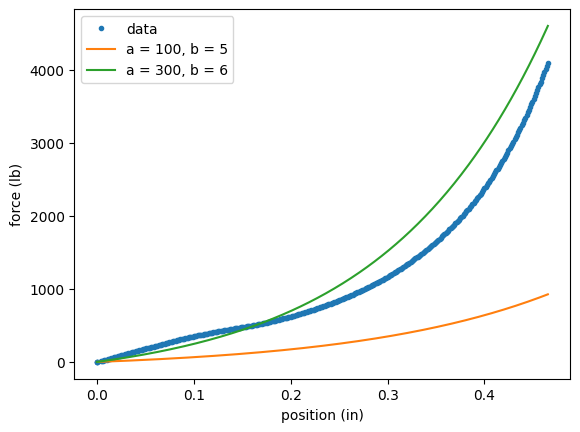

In [11]:
fig, ax = plt.subplots()
ax.plot(position, force, '.', label='data')
ax.plot(position, exp_model(position, 100, 5), label='a = 100, b = 5')
ax.plot(position, exp_model(position, 300, 6), label='a = 300, b = 6')
ax.set_xlabel('position (in)')
ax.set_ylabel('force (lb)')
ax.legend()

Neither guess is close.
Guessing for two parameters is slow.
`curve_fit` runs the search for us.

In [12]:
popt, pcov = optimize.curve_fit(exp_model, position, force)
a_fit, b_fit = popt
print(a_fit, b_fit)

force_exp = exp_model(position, a_fit, b_fit)
print(f'R2 = {r_squared(force, force_exp):.3f}')

215.0882470174925 6.30696023464512
R2 = 0.990


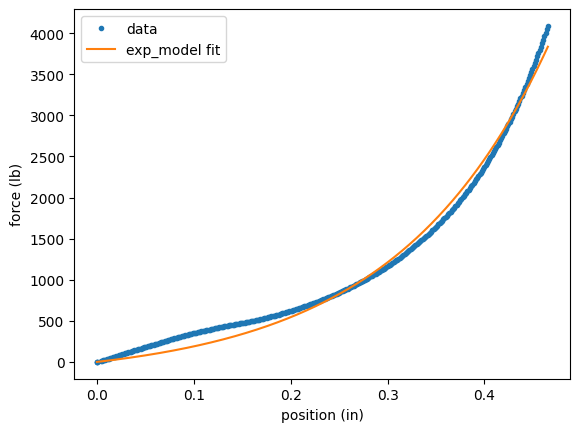

In [13]:
fig, ax = plt.subplots()
ax.plot(position, force, '.', label='data')
ax.plot(position, force_exp, '-', label='exp_model fit')
ax.set_xlabel('position (in)')
ax.set_ylabel('force (lb)')
ax.legend()

R² is 0.99, up from 0.85 for the straight line.
The curve matches the data, but let's check the residuals before we trust it.
A residual is measured force minus fitted force.

Text(0, 0.5, 'residual (lb)')

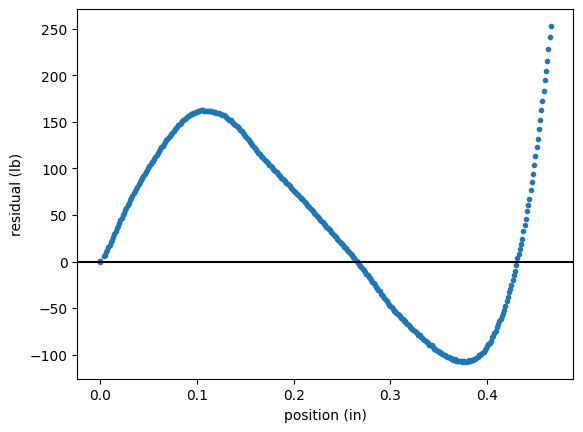

In [14]:
residual_exp = force - force_exp

fig, ax = plt.subplots()
ax.plot(position, residual_exp, '.')
ax.axhline(0, color='black')
ax.set_xlabel('position (in)')
ax.set_ylabel('residual (lb)')

The residuals are not scattered evenly around zero.
They are positive in the middle of the test and negative near the end.
The residuals form a pattern.
Part of the curve's shape is absent from our formula.

We return to this after the first exercise.

### [Check your understanding]

A quadratic, $F = a x^2 + b x + c$, is another shape we can try.

1. Write `quad_model(x, a, b, c)` that returns $a x^2 + b x + c$.
   Call it yourself once, `quad_model(0.2, 1, 1, 1)`, and check the printed value against a hand calculation.
2. Give `quad_model`, `position` and `force` to `optimize.curve_fit`.
   Unpack the result as `popt, pcov` and print `popt`.
3. Compute the fitted force with the three fitted values and print `r_squared(force, force_quad)`.
   Plot the data and the fit.
   Compare it with the R² of 0.990 for the two-parameter `exp_model`.
   Which R² is higher?
4. Rewrite the `def` line as `quad_model(x, c, b, a)`, with the body unchanged, and fit again.
   Which entry of the new `popt` is the coefficient of $x^2$?
   Explain in a sentence how you know.

# Starting guesses

`curve_fit` begins with a set of parameter values and improves them.
Unless we say otherwise, every parameter starts at 1.
We can set the starting values ourselves with `p0`.
It is a list with one starting value per parameter, in the order of the `def` line.

Let's fit a power law, $F = a x^n$.
We read a starting guess off the plot.
At 0.4 in the force is about 2400 lb.
If $n$ is near 2, then $a \approx 2400 / 0.4^2 \approx 15000$.

In [15]:
def power_model(x, a, n):
    """Force in lb from F = a * x**n.

    x:  position in in (a number or an array)
    a:  force scale in lb/in^n
    n:  exponent, unitless
    """
    return a * x**n

popt, pcov = optimize.curve_fit(power_model, position, force, p0=[15000, 2])
a_pow, n_pow = popt
print(a_pow, n_pow)

force_pow = power_model(position, a_pow, n_pow)
print(f'R2 = {r_squared(force, force_pow):.3f}')

22704.946729425188 2.402060905086112
R2 = 0.970


The exponent comes out near 2.4, and R² is 0.97, a little below the exponential's.

A nonlinear fit starts from a guess, so it is worth trying a second one.

In [16]:
popt, pcov = optimize.curve_fit(power_model, position, force, p0=[5000, 1.5])
print(popt)

[2.27049034e+04 2.40205886e+00]


Both starting guesses produce the same fitted values.
That agreement is a useful check for this example, not a guarantee for every nonlinear model.

# Uncertainty in the fitted parameters

The exponential left a pattern in the residuals.
A model with a linear term and an exponential term can reproduce that shape:

$$F = k\,x + b\,(e^{cx} - 1)$$

The first term is a stiffness, $k$ in lb/in, as the part is pushed in.
The second term is the densification at large displacement.
We chose this form for its shape, as we did before.

In [17]:
def two_term(x, k, b, c):
    """Force in lb from F = k * x + b * (exp(c * x) - 1).

    x:  position in in (a number or an array)
    k:  stiffness of the linear term in lb/in
    b:  force scale of the exponential term in lb
    c:  growth rate of the exponential term in 1/in
    """
    return k * x + b * (np.exp(c * x) - 1)

popt, pcov = optimize.curve_fit(two_term, position, force)
k_fit, b_fit, c_fit = popt
force_two = two_term(position, k_fit, b_fit, c_fit)
print(popt)
print(f'R2 = {r_squared(force, force_two):.4f}')

[2717.63973191    9.3865471    12.29163542]
R2 = 0.9993


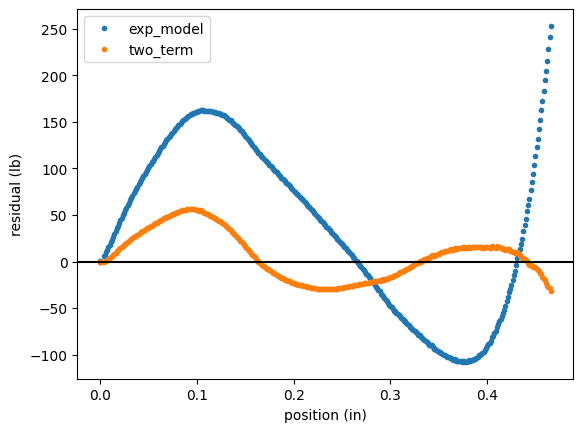

In [18]:
residual_two = force - force_two

fig, ax = plt.subplots()
ax.plot(position, residual_exp, '.', label='exp_model')
ax.plot(position, residual_two, '.', label='two_term')
ax.axhline(0, color='black')
ax.set_xlabel('position (in)')
ax.set_ylabel('residual (lb)')
ax.legend()

The residuals are smaller and the swing is smaller, though a curve is still visible.
The standard deviation of the residuals drops from about 92 lb to about 26 lb.

Now the second item that `curve_fit` returns, `pcov`.

`pcov` is a 2D array with one row and one column per parameter.
Its diagonal holds the variance of each fitted parameter.
The square root of a variance is a standard deviation, and here it is the **standard error** (SE) of the parameter.
We will reuse the line below.

In [19]:
print(pcov.shape)
print(np.diag(pcov))

perr = np.sqrt(np.diag(pcov))
print(perr)

(3, 3)
[5.03171085e+02 2.07341692e-01 1.00673723e-02]
[22.43147532  0.45534788  0.1003363 ]


`perr` is in the same order as `popt` and has the same units.
We report each parameter as the value, plus or minus its SE, with units.
We round the SE to one or two digits and give the value to the same decimal place.

In [20]:
print(f'k = {k_fit:.0f} ± {perr[0]:.0f} lb/in')
print(f'b = {b_fit:.1f} ± {perr[1]:.1f} lb')
print(f'c = {c_fit:.2f} ± {perr[2]:.2f} 1/in')

k = 2718 ± 22 lb/in
b = 9.4 ± 0.5 lb
c = 12.29 ± 0.10 1/in


The fitted values have the following interpretations.

* $k = 2718 \pm 22$ lb/in. The linear term adds about 2700 lb for each inch of compression. The SE is under 1% of the value.
* $c = 12.29 \pm 0.10$ 1/in. Increasing the compression by $1/12.29 = 0.081$ in multiplies the $e^{cx}$ part by $e$.
* $b = 9.4 \pm 0.5$ lb. This has the largest relative SE of the three, about 5% of the value.

`perr` contains SciPy's approximate one-standard-deviation uncertainties for this fitted model.
They describe uncertainty from residual scatter under the fit's assumptions.
They do not measure part-to-part variation from one test, and a small SE is not evidence that the model shape is right.

The residual plot comes first.
Report the fitted data range along with the parameter and SE.

### [Check your understanding]

Return to the toy fit, `my_model` with `x_toy` and `y_toy`.

1. Call `optimize.curve_fit(my_model, x_toy, y_toy)` and unpack the result as `popt, pcov`.
   Compute `perr` from `pcov` in one line.
2. Print `a` and `b` as value ± SE, with the SE rounded to two decimals for `a` and three for `b`.
   Which entry of `popt` and `perr` goes with `a`, and how do you know?
3. Print `perr / popt`, the relative SE of each parameter.
   Which parameter is pinned down less well?
4. Rewrite the `def` line as `my_model(x, b, a)`, with the body unchanged.
   Before you run it, predict how `popt` and `perr` will be ordered.
   Fit again and check your prediction.
5. Fit once more with `p0=[4, 0.5]`.
   Print `popt` and say whether the start changed the result.

# Summary

* A model function for `curve_fit` takes $x$ first and the parameters to fit after it, and returns the predicted $y$.
* `curve_fit(model, x, y)` calls our function many times with trial parameters. We pass the function without parentheses.
* `popt` holds the best-fit values in the order of the `def` line. `pcov` holds their variances on the diagonal.
* `p0=[...]` sets the starting values, one per parameter, in the order of the `def` line. It is worth comparing two starts.
* A residual plot with a pattern shows that the shape of the model is incomplete. R² can be 0.99 and still leave a pattern.
* `perr = np.sqrt(np.diag(pcov))` gives approximate standard errors, in the units of each parameter. They come from residual scatter under the fit's assumptions. We report value ± SE with units and the data range.

## Further reading

* [`scipy.optimize.curve_fit` documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html), including the `p0` and `pcov` descriptions
* Photo credit: compression test, Cjp24, [CC BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0), [Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Compression_test-Universal_testing_machine.jpg)

# Appendix A: Reporting in other units

Optional.
A fitted value and its SE change units together.
We multiply both by the same conversion factor.
One pound-force is 4.448 N and one inch is 25.4 mm.
Multiply lb/in by 4.448 / 25.4 to obtain N/mm.

In [21]:
to_n_per_mm = 4.448 / 25.4

k_si = k_fit * to_n_per_mm
k_si_err = perr[0] * to_n_per_mm
print(f'k = {k_si:.0f} ± {k_si_err:.0f} N/mm')
print(f'relative SE in lb/in: {perr[0] / k_fit:.4f}')
print(f'relative SE in N/mm:  {k_si_err / k_si:.4f}')

k = 476 ± 4 N/mm
relative SE in lb/in: 0.0083
relative SE in N/mm:  0.0083


The relative SE, the SE divided by the value, is the same in either unit.
Converting changes the size of both numbers equally.

# Appendix B: The same model on a different range

Optional.
A fitted value and its SE depend on the model and on the data range we fit.
Here we fit `two_term` again using only the readings below 0.4 in.

In [22]:
mask = position < 0.4
popt_part, pcov_part = optimize.curve_fit(two_term, position[mask], force[mask])
perr_part = np.sqrt(np.diag(pcov_part))

print(f'all readings:     k = {k_fit:.0f} ± {perr[0]:.0f} lb/in,  c = {c_fit:.2f} ± {perr[2]:.2f} 1/in')
print(f'below 0.4 in:     k = {popt_part[0]:.0f} ± {perr_part[0]:.0f} lb/in,  c = {popt_part[2]:.2f} ± {perr_part[2]:.2f} 1/in')

all readings:     k = 2718 ± 22 lb/in,  c = 12.29 ± 0.10 1/in
below 0.4 in:     k = 2927 ± 25 lb/in,  c = 14.62 ± 0.27 1/in


The two sets of values differ by many SEs.
The SE reflects the scatter around `two_term`, and `two_term` describes the curve only approximately.
Each estimate is conditional on the model and on the range of data we fit.